# Dependencies

In [3]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print(tf.__version__)
############ settings ############
data_dir = r"data"

batch_size = 32
img_height = 128
img_width = 128

2.12.0


# Data preprocessing

**- Loading and splitting data<br>**
**- Train:80% and Validation:20%**

In [2]:

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=(img_height, img_width),

    batch_size=batch_size)


val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=(img_height, img_width),

    batch_size=batch_size)

Found 8742 files belonging to 5 classes.
Using 6994 files for training.
Found 8742 files belonging to 5 classes.
Using 1748 files for validation.


In [4]:
class_names = train_ds.class_names
print("Class Names:", class_names)

Class Names: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Viral Pneumonia', 'lung cancer']


# EDA

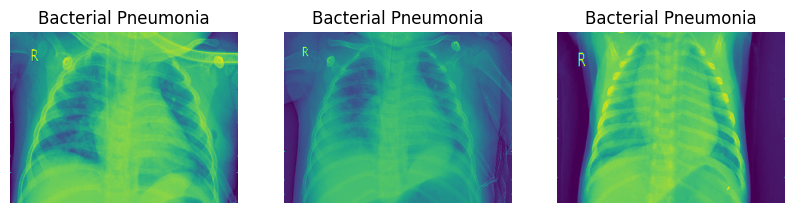

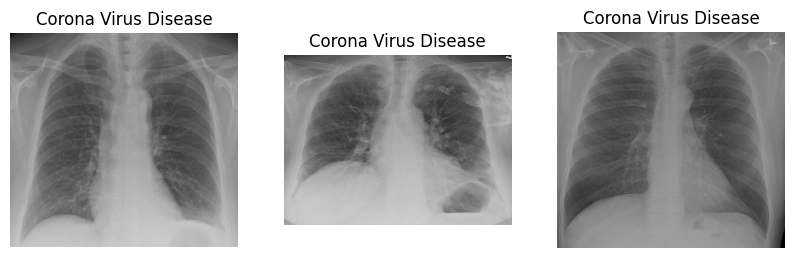

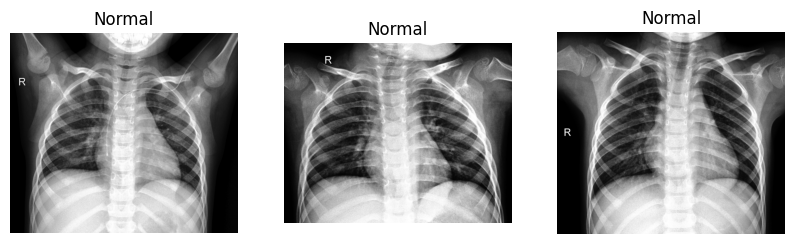

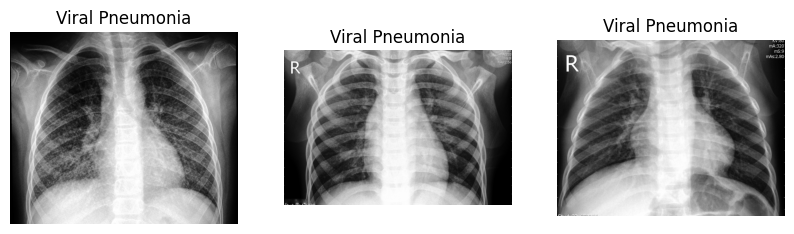

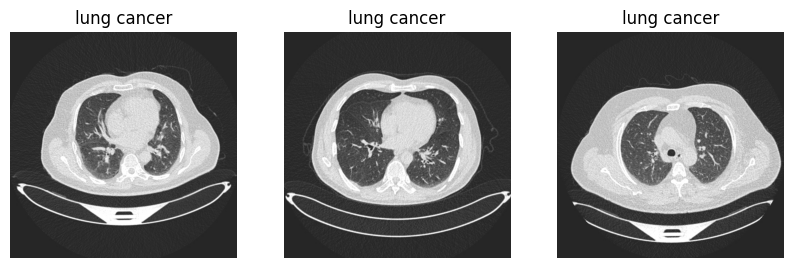

In [5]:
# Sample images
class_names = train_ds.class_names

for class_name in class_names:
    imgs = os.listdir(os.path.join(data_dir, class_name))[:3]
    plt.figure(figsize=(10, 10))
    for i, img in enumerate(imgs):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(plt.imread(os.path.join(data_dir, class_name, img)))
        plt.title(class_name)
        plt.axis('off')

# Model Training

In [6]:
# Configure the dataset for performance

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [41]:
num_classes=len(class_names)
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(img_height, img_width, 3)),
    tf.keras.layers.experimental.preprocessing.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')

])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

earlystop_callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                                      min_delta=0.0001,
                                                      patience=5)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 64)        1

In [42]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=10,
                    callbacks=[earlystop_callback])

Epoch 1/10
219/219 [==============================] - 125s 551ms/step - loss: 0.8338 - accuracy: 0.6456 - val_loss: 0.5544 - val_accuracy: 0.7820
Epoch 2/10
219/219 [==============================] - 88s 402ms/step - loss: 0.5851 - accuracy: 0.7562 - val_loss: 0.4785 - val_accuracy: 0.7941
Epoch 3/10
219/219 [==============================] - 90s 410ms/step - loss: 0.5216 - accuracy: 0.7801 - val_loss: 0.4670 - val_accuracy: 0.8038
Epoch 4/10
219/219 [==============================] - 88s 401ms/step - loss: 0.4837 - accuracy: 0.7978 - val_loss: 0.4419 - val_accuracy: 0.8124
Epoch 5/10
219/219 [==============================] - 91s 416ms/step - loss: 0.4488 - accuracy: 0.8045 - val_loss: 0.4223 - val_accuracy: 0.8112
Epoch 6/10
219/219 [==============================] - 87s 399ms/step - loss: 0.4135 - accuracy: 0.8188 - val_loss: 0.4613 - val_accuracy: 0.8055
Epoch 7/10
219/219 [==============================] - 90s 413ms/step - loss: 0.3945 - accuracy: 0.8290 - val_loss: 0.4364 - val_a

In [43]:
model.save("vgg_capsule.h5")

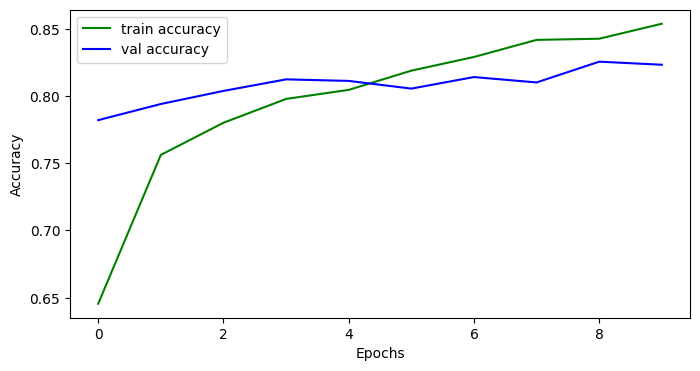

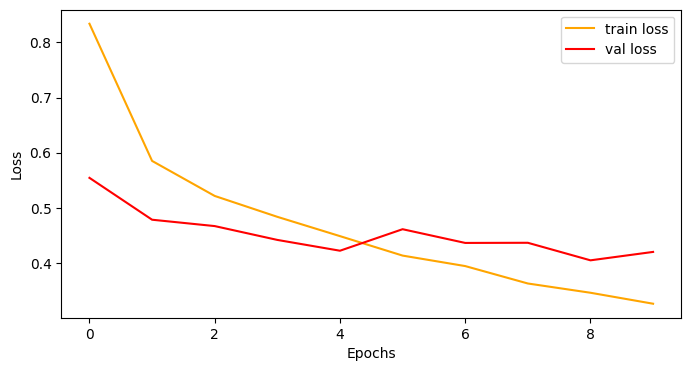

In [44]:

train_loss = history.history['loss']

train_acc = history.history['accuracy']

valid_loss = history.history['val_loss']

valid_acc = history.history['val_accuracy']


# Accuracy plots

plt.figure(figsize=(8, 4))

plt.plot(train_acc, color='green', linestyle='-', label='train accuracy')

plt.plot(valid_acc, color='blue', linestyle='-', label='val accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()


# loss plots

plt.figure(figsize=(8, 4))

plt.plot(train_loss, color='orange', linestyle='-', label='train loss')

plt.plot(valid_loss, color='red', linestyle='-', label='val loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

# Model Evaluation

In [45]:

loss, acc = model.evaluate(val_ds, batch_size=batch_size)

print("validation accuracy :", round(acc, 2))

print("validation loss :", round(loss, 2))

55/55 [==============================] - 7s 117ms/step - loss: 0.4201 - accuracy: 0.8232
validation accuracy : 0.82
validation loss : 0.42


In [46]:

y_pred = []  # store predicted labels

y_true = []  # store true labels


# iterate over the dataset

for image_batch, label_batch in val_ds:   # use dataset.unbatch() with repeat
    # append true labels
    y_true.append(label_batch)
    # compute predictions
    preds = model.predict(image_batch)
    # append predicted labels
    y_pred.append(np.argmax(preds, axis=- 1))


# convert the true and predicted labels into tensors

correct_labels = tf.concat([item for item in y_true], axis=0)

predicted_labels = tf.concat([item for item in y_pred], axis=0)

1/1 [==============================] - 0s 315ms/step


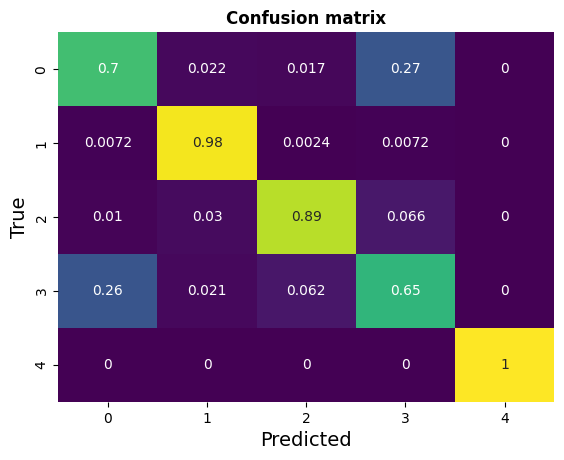

In [47]:

cm = confusion_matrix(correct_labels, predicted_labels, normalize='true')

sns.heatmap(cm, annot=True, cmap='viridis', cbar=None)

plt.title("Confusion matrix", fontweight='bold')

plt.ylabel("True", fontsize=14)

plt.xlabel("Predicted", fontsize=14)

plt.show()

In [48]:
print(classification_report(correct_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.73      0.70      0.71       414
           1       0.93      0.98      0.96       416
           2       0.92      0.89      0.91       396
           3       0.65      0.65      0.65       387
           4       1.00      1.00      1.00       135

    accuracy                           0.82      1748
   macro avg       0.84      0.85      0.84      1748
weighted avg       0.82      0.82      0.82      1748



# Post Processing

In [49]:
def prediction(img):
    class_names = ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Viral Pneumonia', 'lung cancer']

    my_image = load_img(img, target_size=(img_height, img_width))
    my_image = img_to_array(my_image)
    my_image = np.expand_dims(my_image, 0)

    out = np.round(model.predict(my_image)[0], 2)
    fig = plt.figure(figsize=(7, 4))
    plt.barh(class_names, out, color='lightgray',
             edgecolor='red', linewidth=1, height=0.5)

    for index, value in enumerate(out):
        plt.text(value/2 + 0.1, index, f"{100*value:.2f}%", fontweight='bold')

    plt.xticks([])
    plt.yticks([0, 1, 2,3,4], labels=class_names, fontweight='bold', fontsize=14)
    fig.savefig('pred_img.png', bbox_inches='tight')
    return plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load your saved model
model = load_model('vgg_capsule.h5')

# Define the prediction function
def prediction(img):
    class_names = ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Viral Pneumonia', 'lung cancer']

    my_image = load_img(img, target_size=(128, 128))  # Adjust the target size to your model's input size
    my_image = img_to_array(my_image)
    my_image = np.expand_dims(my_image, axis=0)

    out = np.round(model.predict(my_image)[0], 2)
    fig = plt.figure(figsize=(7, 4))
    plt.barh(class_names, out, color='lightgray', edgecolor='red', linewidth=1, height=0.5)

    for index, value in enumerate(out):
        plt.text(value/2 + 0.1, index, f"{100*value:.2f}%", fontweight='bold')

    plt.xticks([])
    plt.yticks([0, 1, 2, 3, 4], labels=class_names, fontweight='bold', fontsize=14)
    fig.savefig('pred_img.png', bbox_inches='tight')
    plt.show()



In [6]:
# Prediction on single Image
img = r'C:\Users\Pavithra\OneDrive\Desktop\new\data\Corona Virus Disease\_7_3751775.jpeg'
prediction(img)

NameError: name 'prediction' is not defined